# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Deisa Anggella Adista
- **Email:** cdcc525d6x0090@student.devacademy.id
- **ID Dicoding:** CDCC525D6X0090

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana tren volume pesanan (order) bulanan di platform e-commerce secara spesifik selama tahun 2018, dan pada bulan apa terjadi lonjakan transaksi tertinggi?
- **Pertanyaan 2:** Berdasarkan keseluruhan data operasional (2016-2018), kota mana saja yang mendominasi top 10 jumlah pelanggan terbanyak?
- **Pertanyaan 3:** Kategori produk apa yang mencatatkan kuantitas penjualan tertinggi (Top 5) dan terendah (Bottom 5) selama periode 2016-2018? **(pertanyaan tambahan dari saya sendiri)**

## Import Semua Packages/Library yang Digunakan

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style untuk visualisasi
sns.set(style='darkgrid')

## Data Wrangling

### Gathering Data

In [87]:
# Load dataset
customers = pd.read_csv("customers_dataset.csv")
orders = pd.read_csv("orders_dataset.csv")
order_items = pd.read_csv("order_items_dataset.csv")
products = pd.read_csv("products_dataset.csv")
product_category_translation = pd.read_csv("product_category_name_translation.csv")

# Preview data singkat
print("Data Customers:", customers.shape)
print("Data Orders:", orders.shape)
print("Data Order Items:", order_items.shape)
print("Data Products:", products.shape)
print("Data Category Translation:", product_category_translation.shape)

Data Customers: (99441, 5)
Data Orders: (99441, 8)
Data Order Items: (112650, 7)
Data Products: (32951, 9)
Data Category Translation: (71, 2)


**Insight:**
- Kelima dataset utama telah berhasil dimuat. Dataset `customers`, `orders`, dan `order_items` digunakan untuk menganalisis tren waktu dan sebaran geografis pelanggan
- Dataset `products` dan `product_category_name_translation` dimuat untuk menganalisis performa kategori produk dalam bahasa Inggris agar lebih mudah dipahami

### Assessing Data

In [88]:
# Cek info dataset orders
orders.info()

# Cek missing value
print("\nMissing value di orders:\n", orders.isnull().sum())
print("\nMissing value di customers:\n", customers.isnull().sum())
print("\nMissing value di order_items:\n", order_items.isnull().sum())

# Cek duplikasi data
print("\nJumlah duplikasi orders:", orders.duplicated().sum())
print("Jumlah duplikasi customers:", customers.duplicated().sum())
print("Jumlah duplikasi order_items:", order_items.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

Missing value di orders:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_d

**Insight:**
- Terdapat missing value pada tabel `orders` (misal pada `order_approved_at` dan `order_delivered_customer_date`). Ini wajar karena beberapa pesanan mungkin dibatalkan atau belum sampai
- Kolom tanggal seperti `order_purchase_timestamp` masih bertipe `object` (string) dan perlu diubah menjadi `datetime`
- Tidak ditemukan adanya data duplikat pada dataset yang digunakan

### Cleaning Data

In [89]:
# Hapus missing value pada tabel orders dan gunakan .copy()
orders_clean = orders.dropna().copy()

# Ubah tipe data kolom waktu menjadi datetime
orders_clean['order_purchase_timestamp'] = pd.to_datetime(orders_clean['order_purchase_timestamp'])

# Merge dataset menjadi satu DataFrame komprehensif (df)
df = orders_clean.merge(customers, on="customer_id")
df = df.merge(order_items, on="order_id")
df = df.merge(products, on="product_id", how="left")
df = df.merge(product_category_translation, on="product_category_name", how="left")

# Cek hasil penggabungan
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110180 entries, 0 to 110179
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110180 non-null  object        
 1   customer_id                    110180 non-null  object        
 2   order_status                   110180 non-null  object        
 3   order_purchase_timestamp       110180 non-null  datetime64[ns]
 4   order_approved_at              110180 non-null  object        
 5   order_delivered_carrier_date   110180 non-null  object        
 6   order_delivered_customer_date  110180 non-null  object        
 7   order_estimated_delivery_date  110180 non-null  object        
 8   customer_unique_id             110180 non-null  object        
 9   customer_zip_code_prefix       110180 non-null  int64         
 10  customer_city                  110180 non-null  object        
 11  

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


**Insight:**
- Missing value pada pesanan yang tidak tuntas telah dibersihkan. Tipe data waktu sudah dikonversi ke `datetime64`.
- Proses penggabungan (merge) berhasil menyatukan informasi pelanggan, detail pesanan, dan terjemahan kategori produk ke dalam satu tabel utama (`df`) yang siap untuk dieksplorasi.

## Exploratory Data Analysis (EDA)

### Explore Data Pesanan, Pelanggan, dan Produk

In [90]:
# EDA Pertanyaan 1: Tren 2018
# Filter data khusus tahun 2018
df_2018 = df[df['order_purchase_timestamp'].dt.year == 2018].copy()

# Buat kolom 'year_month' berformat 'YYYY-MM'
df_2018['year_month'] = df_2018['order_purchase_timestamp'].dt.strftime('%Y-%m')

# Menghitung jumlah pesanan unik per bulan
monthly_orders = df_2018.groupby('year_month')['order_id'].nunique().reset_index()
monthly_orders.columns = ['year_month', 'order_count']
print("Tren Bulanan 2018:")
display(monthly_orders.head())

# EDA Pertanyaan 2: Demografi Kota
top_cities = df['customer_city'].value_counts().head(10).reset_index()
top_cities.columns = ['customer_city', 'customer_count']
print("\nTop 10 Kota Pelanggan:")
display(top_cities.head())

# EDA Pertanyaan 3: Performa Produk
# 5 Kategori Produk Terlaris
top_products = df['product_category_name_english'].value_counts().head(5).reset_index()
top_products.columns = ['product_category', 'quantity_sold']
print("\n5 Kategori Produk Terlaris:")
display(top_products)

# 5 Kategori Produk Paling Sedikit Terjual
worst_products = df['product_category_name_english'].value_counts().sort_values(ascending=True).head(5).reset_index()
worst_products.columns = ['product_category', 'quantity_sold']
print("\n5 Kategori Produk Paling Sedikit Terjual:")
display(worst_products)

Tren Bulanan 2018:


,year_month,order_count
0,2018-01,7069
1,2018-02,6556
2,2018-03,7003
3,2018-04,6798
4,2018-05,6749



Top 10 Kota Pelanggan:


,customer_city,customer_count
0,sao paulo,17400
1,rio de janeiro,7593
2,belo horizonte,3087
3,brasilia,2341
4,curitiba,1727



5 Kategori Produk Terlaris:


,product_category,quantity_sold
0,bed_bath_table,10952
1,health_beauty,9467
2,sports_leisure,8429
3,furniture_decor,8156
4,computers_accessories,7643



5 Kategori Produk Paling Sedikit Terjual:


,product_category,quantity_sold
0,security_and_services,2
1,fashion_childrens_clothes,7
2,la_cuisine,14
3,cds_dvds_musicals,14
4,arts_and_craftmanship,24


**Insight:**
- Pada tahun 2018, volume pesanan bulanan berhasil diakumulasi untuk melihat pergerakan tren.
- Kota Sao Paulo adalah penyumbang pelanggan terbanyak.
- Kategori produk telah berhasil dipisahkan menjadi 5 kategori terlaris (seperti *bed_bath_table*) dan 5 kategori dengan performa terburuk (seperti *security_and_services*).

## Visualization & Explanatory Analysis

### Pertanyaan 1: Tren jumlah order per bulan tahun 2018

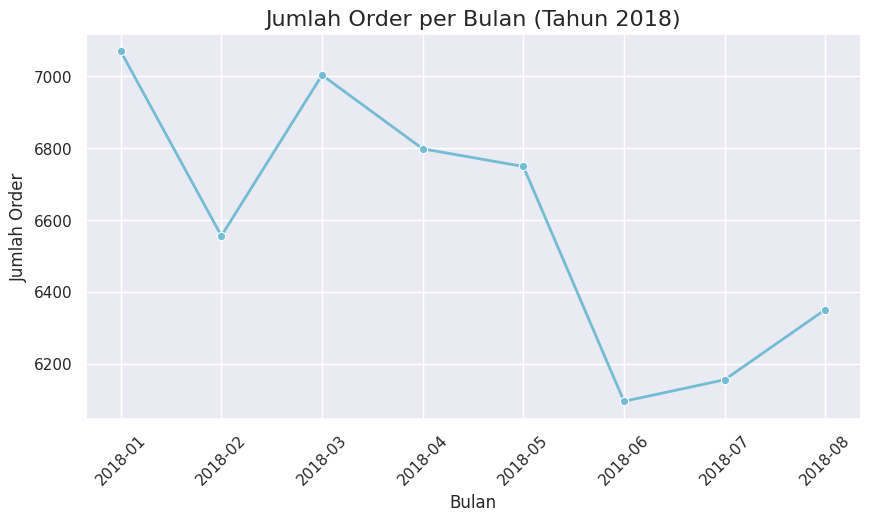

In [91]:
plt.figure(figsize=(10, 5))
sns.lineplot(x='year_month', y='order_count', data=monthly_orders, marker='o', color="#72BCD4", linewidth=2)
plt.title("Jumlah Order per Bulan (Tahun 2018)", fontsize=16)
plt.xlabel("Bulan", fontsize=12)
plt.ylabel("Jumlah Order", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Pertanyaan 2: Top 10 Kota dengan Pelanggan Terbanyak

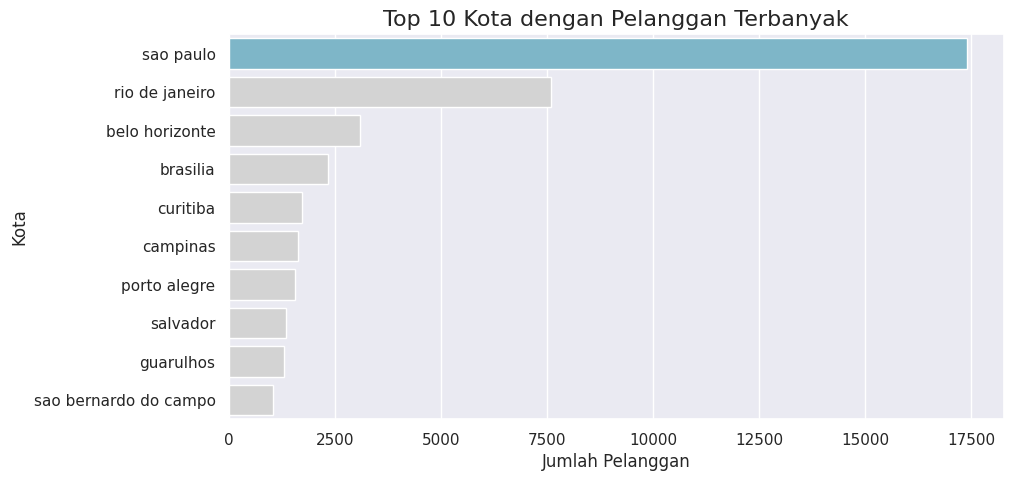

In [92]:
plt.figure(figsize=(10, 5))
colors = ["#72BCD4" if i == 0 else "#D3D3D3" for i in range(len(top_cities))]

sns.barplot(
    x='customer_count',
    y='customer_city',
    data=top_cities,
    palette=colors,
    hue='customer_city',
    legend=False
)
plt.title("Top 10 Kota dengan Pelanggan Terbanyak", fontsize=16)
plt.xlabel("Jumlah Pelanggan", fontsize=12)
plt.ylabel("Kota", fontsize=12)
plt.show()

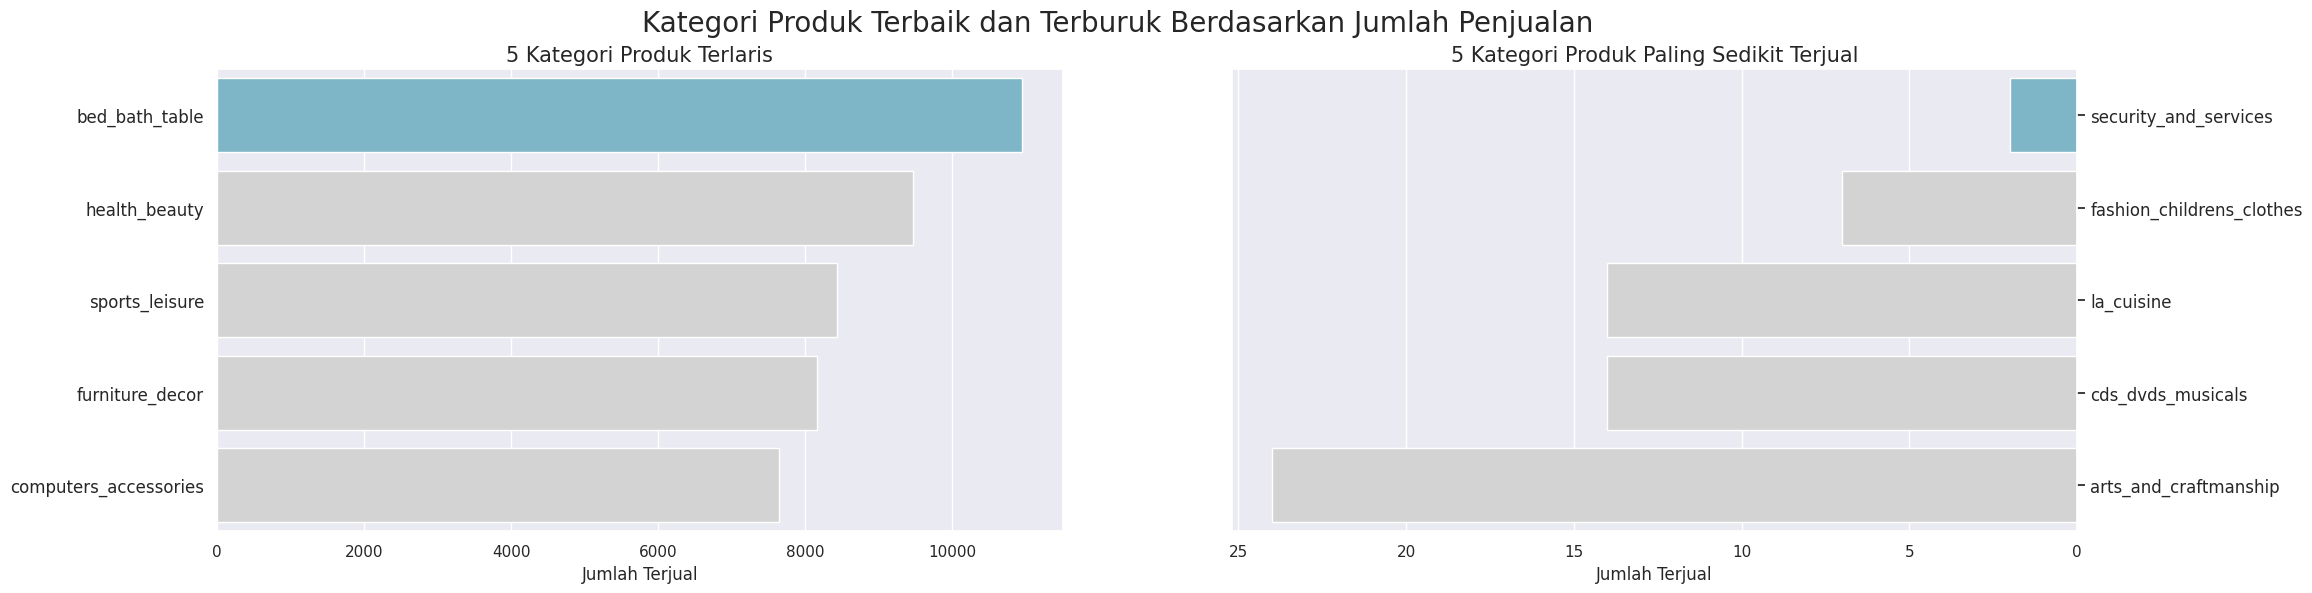

In [93]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

# Best Performing Product
sns.barplot(
    x="quantity_sold",
    y="product_category",
    data=top_products,
    palette=colors,
    hue="product_category",
    legend=False,
    ax=ax[0]
)
ax[0].set_ylabel(None)
ax[0].set_xlabel("Jumlah Terjual")
ax[0].set_title("5 Kategori Produk Terlaris", loc="center", fontsize=15)
ax[0].tick_params(axis='y', labelsize=12)

# Worst Performing Product
sns.barplot(
    x="quantity_sold",
    y="product_category",
    data=worst_products,
    palette=colors,
    hue="product_category",
    legend=False,
    ax=ax[1]
)
ax[1].set_ylabel(None)
ax[1].set_xlabel("Jumlah Terjual")
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("5 Kategori Produk Paling Sedikit Terjual", loc="center", fontsize=15)
ax[1].tick_params(axis='y', labelsize=12)

plt.suptitle("Kategori Produk Terbaik dan Terburuk Berdasarkan Jumlah Penjualan", fontsize=20)
plt.show()

- Tren Pesanan (2018): Cukup stabil di angka 6.000-7.000 transaksi/bulan (Jan-Ags)
- Demografi Pelanggan: Sangat terpusat di wilayah tenggara Brazil. Kota Sao Paulo menjadi penyumbang pelanggan terbanyak, disusul Rio de Janeiro dan Belo Horizonte
- Performa Produk: Sangat didominasi oleh produk kebutuhan sehari-hari

## Analisis Lanjutan (Opsional)
RFM Analysis digunakan untuk mengelompokkan pelanggan berdasarkan:
- **Recency**: Kapan terakhir pelanggan melakukan transaksi (dalam hari)
- **Frequency**: Seberapa sering pelanggan berbelanja
- **Monetary**: Berapa total uang yang dihabiskan pelanggan

In [94]:
# 1. Menentukan tanggal transaksi terakhir di dataset sebagai referensi
recent_date = df['order_purchase_timestamp'].dt.date.max()

# 2. Membuat DataFrame RFM
rfm_df = df.groupby('customer_id', as_index=False).agg({
    'order_purchase_timestamp': 'max', # Recency
    'order_id': 'nunique',             # Frequency
    'price': 'sum'                     # Monetary
})

# 3. Mengganti nama kolom
rfm_df.columns = ['customer_id', 'max_order_timestamp', 'frequency', 'monetary']

# 4. Menghitung Recency (selisih hari)
rfm_df['max_order_timestamp'] = rfm_df['max_order_timestamp'].dt.date
rfm_df['recency'] = rfm_df['max_order_timestamp'].apply(lambda x: (recent_date - x).days)
rfm_df.drop('max_order_timestamp', axis=1, inplace=True)

rfm_df.head()

,customer_id,frequency,monetary,recency
0,00012a2ce6f8dcda20d059ce98491703,1,89.80,288
1,000161a058600d5901f007fab4c27140,1,54.90,409
2,0001fd6190edaaf884bcaf3d49edf079,1,179.99,547
3,0002414f95344307404f0ace7a26f1d5,1,149.90,378
4,000379cdec625522490c315e70c7a9fb,1,93.00,149


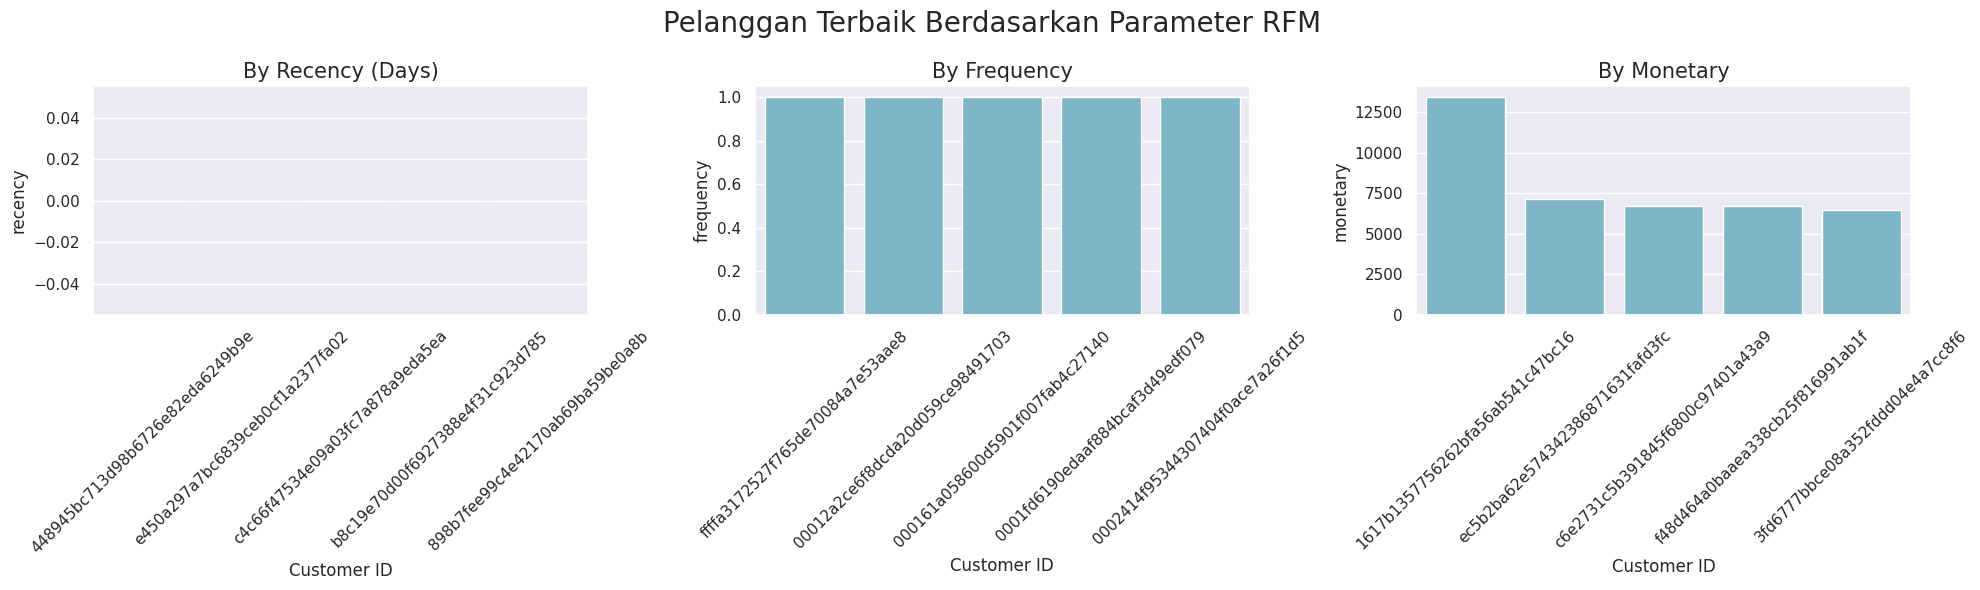

In [95]:
# Menampilkan 5 pelanggan terbaik berdasarkan tiap metrik
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
colors_rfm = ["#72BCD4"] * 5

# Recency
sns.barplot(
    y="recency", x="customer_id",
    data=rfm_df.sort_values(by="recency", ascending=True).head(5),
    palette=colors_rfm, hue="customer_id", legend=False, ax=ax[0]
)
ax[0].set_title("By Recency (Days)", fontsize=15)
ax[0].set_xlabel("Customer ID")
ax[0].tick_params(axis='x', rotation=45)

# Frequency
sns.barplot(
    y="frequency", x="customer_id",
    data=rfm_df.sort_values(by="frequency", ascending=False).head(5),
    palette=colors_rfm, hue="customer_id", legend=False, ax=ax[1]
)
ax[1].set_title("By Frequency", fontsize=15)
ax[1].set_xlabel("Customer ID")
ax[1].tick_params(axis='x', rotation=45)

# Monetary
sns.barplot(
    y="monetary", x="customer_id",
    data=rfm_df.sort_values(by="monetary", ascending=False).head(5),
    palette=colors_rfm, hue="customer_id", legend=False, ax=ax[2]
)
ax[2].set_title("By Monetary", fontsize=15)
ax[2].set_xlabel("Customer ID")
ax[2].tick_params(axis='x', rotation=45)

plt.suptitle("Pelanggan Terbaik Berdasarkan Parameter RFM", fontsize=20)
plt.tight_layout()
plt.show()

In [96]:
# Memilih 6 kolom yang HANYA digunakan di dashboard
columns_to_use = [
    "order_id",
    "customer_id",
    "order_purchase_timestamp",
    "customer_city",
    "product_category_name_english",
    "price"
]

# Pandas akan langsung memotong data dan menyimpannya sebagai file ZIP!
df[columns_to_use].to_csv("main_data.zip", index=False, compression="zip")

print("Selesai! File main_data.zip sudah dibuat dan ukurannya pasti sangat kecil.")

Selesai! File main_data.zip sudah dibuat dan ukurannya pasti sangat kecil.


## Conclusion

## Conclusion & Rekomendasi Bisnis

**1. Conclusion Pertanyaan 1 (Tren Pesanan 2018):**
Tren pesanan selama tahun 2018 cenderung stabil dari bulan Januari hingga Agustus di kisaran 6.000-7.000 transaksi. Penurunan di bulan September-Oktober terjadi karena batas akhir pengumpulan dataset

**Rekomendasi:** Tim operasional dan logistik harus memastikan kapasitas server dan ketersediaan kurir selalu dalam kondisi maksimal pada periode stabil (Januari-Agustus) setiap tahunnya untuk mencegah *bottleneck* pengiriman

**2. Conclusion Pertanyaan 2 (Demografi Kota 2016-2018):**
Kota Sao Paulo mendominasi secara absolut dengan lebih dari 15.000 pelanggan, disusul oleh Rio de Janeiro dan Belo Horizonte. Infrastruktur e-commerce sangat terpusat di wilayah tenggara Brazil

**Rekomendasi:** Tim Marketing dapat memfokuskan anggaran kampanye utama (seperti *Free Shipping*) di Top 3 kota tersebut untuk menjaga loyalitas pelanggan. Untuk memperluas jangkauan pasar, perusahaan perlu memberikan promo khusus "Pengguna Baru" di kota-kota peringkat bawah untuk memancing pertumbuhan pasar baru

**3. Conclusion Pertanyaan 3 (Performa Produk 2016-2018):**
Kategori *bed_bath_table* dan *health_beauty* adalah yang paling mendominasi penjualan di platform dengan angka penjualan tertinggi. Sebaliknya, kategori spesifik seperti *security_and_services* hampir tidak ada peminatnya

**Rekomendasi:** Tim Bisnis (Inventory) disarankan untuk menambah variasi merek dan stok pada kategori kebutuhan rumah tangga dan perawatan diri. Untuk produk yang kurang laku, perusahaan bisa menerapkan strategi *bundling* dengan produk terlaris atau mengurangi *supply* agar tidak membebani biaya gudang